(sec:modello-bernoulliano)=
# Le distribuzioni di Bernoulli

Il tipo più semplice di modello casuale è quello nel quale l'esecuzione di
un esperimento ha due soli possibili esiti. Esperimenti di questo tipo,
che vengono tipicamente chiamati _esperimenti di Bernoulli_, danno luogo a
una famiglia di distribuzioni di probabilità che è anch'essa detta
_famiglia di Bernoulli_.

## Il modello di Bernoulli

Si usa generalmente il termine _esperimento di Bernoulli_ per indicare un
esperimento casuale ha due soli possibili esiti, che vengono convenzionalmente
indicati come «successo» e «fallimento», così che lo spazio degli eventi
risulta essere  $\Omega = \{ \text{fallimento}, \text{successo} \}$. 

```{prf:example}
Le denominazioni «successo» e «fallimento» non hanno generalmente le
connotazioni positive e negative che diamo loro nel linguaggio comune, ma come
_etichette_ usate per rappresentare in modo astratto i due esiti
dell'esperimento in questione. Se l'esecuzione dell'esperimento consiste
nel selezionare secondo qualche criterio non deterministico un fumetto
all'interno di una pila, il successo potrebbe essere associato all'estrazione
di un volume
- con una pagina strappata,
- che contiene almeno una storia della nostra supereroina preferita,
- in cui c'è almeno una vignetta con un personaggio che indossa un
  cappotto blu.

In linea generale, queste tre situazioni vengono valutate rispettivamente in
modo negativo, positivo e neutro, ma in tutti i casi ci stiamo riferendo al
successo in un esperimento di Bernoulli. Vale la pena sottolineare che
in modo del tutto analogo potremmo pensare a esperimenti di Bernoulli,
un un certo senso duali rispetto a quelli sopra indicati, nei quali i medesimi
avvenimenti identificano il fallimento.
```

Dato un generico esperimento di Bernoulli, sia $p \in [0, 1]$ la probabilità
di ottenere un successo come esito. La variabile aleatoria
$X: \Omega \to \{ 0, 1 \}$ definita in modo tale che

```{math}
X(w) = \begin{cases}
       0 & \text{se $w = \text{fallimento}$,} \\
       1 & \text{se $w = \text{successo}$,}
       \end{cases}
```

segue una distribuzione detta _di Bernoulli_, parametrizzata rispetto alla
probabilità di successo $p$ e il cui supporto è l'insieme $\{ 0, 1 \}$.
Chiaramente, gli eventi $X =0$ e $X = 1$ avranno rispettivamente probabilità
uguali a $1 - p$ e $p$, da cui segue la prossima definizione.

````{prf:definition} La famiglia delle distribuzioni di Bernoulli
:label: def:bernoulli-distribution

Dato $p \in [0, 1]$, la distribuzione di Bernoulli di parametro $p$ è
definita dalla funzione di massa di probabilità

```{math}
f(x; p) = p^x (1 - p)^{1 - x} \mathrm I_{\{ 0, 1 \}}(x)
```

o, equivalentemente, dalla funzione di ripartizione

```{math}
F(x; p) = (1 -  p) \mathrm I_{[0, 1)}(x) + \mathrm I_{[1, +\infty)}(x)
          \enspace.
```

Scriveremo $X \sim \mathrm B(p)$ per indicare che la variabile aleatoria $X$
segue una distribuzione di Bernoulli di parametro $p$. L'insieme di tutte
le distribuzioni di Bernoulli al variare dei possibili valori per il
relativo parametro viene detta _famiglia delle distribuzioni di Bernoulli_.
````

Chiaramente, la visualizzazione di questo tipo di funzione di massa di
probabilità consiste nel mostrare due bastoncini aventi
ascisse nulla e unitaria e altezza uguale a $1-p$ e $p$, mentre la funzione
di ripartizione avrà un grafico costante a tratti, con due salti posizionati
nelle stesse ascisse: il primo cambierà l'ordinata da $0$ a $1 - p$ e il
secondo la modificherà da quest'ultimo valore a $1$, come evidenziato nel
grafico prodotto dalla seguente cella nascosta, nel quale la spezzata blu
mostra il grafico della funzione di ripartizione e il grafico a bastoncini
indica la funzione di massa di probabilità. Nella versione interattiva del
libro è anche possibile modificare il valore del parametro $p$ agendo sul
relativo selettore e vedere come cambiano i due grafici.

In [1]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st

param_slider = widgets.FloatSlider(value=0.75,
                                        min=0,
                                        max=1,
                                        step=0.01,
                                        description='p',
                                        continuous_update=True,
                                        readout=False,
                                        orientation='horizontal')

def bernoulli_pdf_cdf(p):
    B = st.bernoulli(p)

    plt.hlines([0, B.pmf(0), 1], [-1, 0, 1], [0, 1, 2])

    plt.vlines([0, 1], 0, [B.pmf(0), B.pmf(1)], color='k')
    plt.plot([0, 1], [B.pmf(0), B.pmf(1)], 'o')

    plt.title(rf'$p = {p:.2f}$')
    plt.show()

widgets.interactive(bernoulli_pdf_cdf, p = param_slider)

interactive(children=(FloatSlider(value=0.75, description='p', max=1.0, readout=False, step=0.01), Output()), …

```{figure} https://upload.wikimedia.org/wikipedia/commons/1/19/Jakob_Bernoulli.jpg
---
figclass: margin
name: fig:jakob-bernoulli
width: 200px
align: left
---
Ritratto di Jakob Bernoulli (immagine di pubblico dominio, disponibile su
wikimedia).
```
````{admonition} Nomenclatura
:class: naming

Questa distribuzione deve il suo nome allo scienziato svizzero Jakob
Bernoulli (ritratto nella {numref}`Figura %s <fig:jakob-bernoulli>`, e da non
confondere con il figlio Daniel, anch'esso noto matematico), che la introduce
nel suo libro «Ars Conjectandi», considerato una tra le prime  opere che
trattano della teoria delle probabilità. Nella terminologia comune, e in
alcuni casi anche in fonti scritte in lingua italiana, è abbastanza comune
rimpiazzare la dicitura "di Bernoulli" con l'aggettivo _bernoulliano_, o
perfino _bernulliano_ (in alcuni casi con iniziale maiuscola) quando si vuole
definire un esperimento di questo tipo o le distribuzioni e variabili
aleatorie ad esso collegate. Dunque è possibile imbattersi nelle diciture
«esperimento bernoulliano», «distribuzione Bernoulliana», «variabile aleatoria
bernoulliana» e così via.
````

## Valore atteso e varianza della distribuzione di Bernoulli

Il fatto che siano presenti due sole specificazioni permette di ottenere
agevolmente il valore atteso e la varianza della distribuzione calcolando
estensivamente le sommatorie alla base dei corrispondenti valori attesi.
Infatti, data una variabile aleatoria $X \sim \mathrm B(p)$,

\begin{equation*}
\mathbb E(X) = \sum_{i=0}^1 i \; \mathbb P(X = i) = 0 \cdot (1 - p) + 1 \cdot p
             = p \enspace.
\end{equation*}

D'altra parte, $X^2 = X$ perché elevare $0$ oppure $1$ al quadrato non ne
cambia il valore, e quindi $\mathbb E(X^2) = \mathbb E(X) = p$, il che implica
$\mathrm{Var}(X) = \mathbb E(X^2) - \mathbb E(X)^2 = p - p^2 = p (1 - p)$.

La distribuzione di Bernoulli è decisamente semplice da trattare, essendo
la relativa algebra formata dai soli quattro eventi

```{math}
\mathcal A = \{ \emptyset, \text{fallimento}, \text{successo}, \Omega \}
```

che hanno rispettivamente probabilità $0$, $1-p$, $p$ e $1$. Normalmente,
la parte più impegnativa legata al calcolo delle probabilità di questi eventi
consiste nel determinare correttamente il valore del parametro $p$ partendo
dalla descrizione dell'esperimento di Bernoulli dal quale si parte. In alcuni
casi la probabilità di successo si determina in modo elementare, mentre in
altri è necessario ricorrere alle tecniche di combinatorica che abbiamo visto
nel {numref}`Capitolo %s <cap:calcolo-combinatorio>`.

```{prf:example}
:label: ex:bernoulli

Uno scatolone contiene 50 albi di fumetti, in dodici dei quali compare una e
una sola storia con Aquaman come protagonista, mentre nei restanti albi
Aquaman non compare mai. Scelgo a caso due albi dallo scatolone e indico con
$X$ la variabile aleatoria che assume il valore $1$ quando negli albi che ho
pescato posso leggere due storie diverse di Aquaman, e che vale $0$ in tutti
gli altri casi. Chiaramente $X$ segue una distribuzione di Bernoulli, e il
suo parametro è uguale alla probabilità $p$ che selezionando due albi dai 50 a
disposizione, entrambi facciano parte del gruppo di dodici che parlano di
Aquaman. A sua volta, $p$ è uguale al rapporto tra il numero di combinazioni
di dodici oggetti in due posti (il numero di casi favorevoli) e il numero di
combinazioni di cinquanta oggetti in due posti (il numero di casi possibili),
pertanto

\begin{equation*}
p = \frac{\binom{12}{2}}{\binom{50}{2}} = \frac{12 \cdot 11}{50 \cdot 49}
  \approx 0.054 \enspace,
\end{equation*}

e dunque $X \sim \mathrm B(0.054)$. Pertanto
- la probabilità di non pescare albi con due storie di Aquaman differenti è
  $\mathbb P(X = 0) = 0.946$, e
- $\mathbb E(X) = 0.054$, il che significa che mediamente possiamo aspettarci
  che in poco più di cinque volte su cento selezioni casuali di due albi si
  arrivi a pescarne due con due storie diverse di Aquaman.

Se sapessimo che sei delle dodici copie in questione sono dei doppioni tutti
identici tra loro, ci troveremmo di fronte a una variabile aleatoria $X'$ che
segue ancora distribuzione di Bernoulli, ma in questo il calcolo del relativo
parametro richiede un po' più di perizia. In particolare, quello che si
complica è il calcolo del numero di casi favorevoli. Per ottenerlo possiamo
seguire, per esempio, uno dei due seguenti ragionamenti:

- il numero di modi di scegliere due albi dai dodici a
  disposizione è $\binom{12}{2} = 66$, ma $\binom{6}{2} = 15$ di questi
  corrispondono a coppie che contengono due albi uguali, dunque il numero di
  coppie con albi distinti è $66 - 15 = 51$;
- ci sono $\binom{6}{2} = 15$ modi di comporre una coppia considerando solo
  gli albi di cui possediamo un'unica copia, e a questi   bisogna aggiungere
  $6 \cdot 6 = 36$, che corrisponde al numero di possibili coppie che
  contengono uno dei doppioni e un altro albo; il risultato è, anche in questo
  caso, $51$.

La probabilità $p'$ di estrarre due albi con due storie diverse di Aquaman in
è quindi

\begin{equation*}
p' = \frac{51}{\frac{50 \cdot 49}{2}}
   \approx 0.041 \enspace.
\end{equation*}

Riassumendo, $X' \sim \mathrm B(0.042)$, il che significa ad esempio che la
media del numero di volte in cui si arriva a leggere due storie diverse di
Aquaman scende a poco più di quattro volte su cento.
```


## Momenti della distribuzione di Bernoulli (*)

La funzione generatrice dei momenti per una distribuzione di Bernoulli si
ottiene facilmente, assumendo questa distribuzione solamente due
specificazioni. Infatti, dati $p \in [0, 1]$ e $X \sim \mathrm B(p)$,

\begin{equation*}
m_X(t) = \mathbb E\left( \mathrm e^{tX} \right)
       = (1 - p) \mathrm e^0 + p \mathrm e^t
       = 1 + p \left( \mathrm e^t - 1 \right) \enspace.
\end{equation*}

Pertanto il momento primo della distribuzione è

\begin{equation*}
\mu = m_X'(0) = \left. p \mathrm e^t \right|_{t=0} = p \enspace,
\end{equation*}

che coincide con il valore atteso che abbiamo già calcolato. Per quanto
riguarda invece i momenti centrali, poniamo $Y \coloneqq X - p$ e calcoliamo

\begin{equation*}
m_Y(t) = \mathbb E \left( \mathrm e^{tY} \right)
       = (1 - p) \mathrm e^{-tp} + p \mathrm e^{t(1-p)} \enspace,
\end{equation*}

così che il momento centrale $n$-esimo sarà uguale a

\begin{align*}
\mu_n = m_Y^{(n)}(0) &= \left. p (1 - p)
                        \left( (1 - p)^{n-1} \mathrm e^{t(1-p)}
                               + (-1)^n p^{n-1} \mathrm e^{-tp} \right)
                       \right|_{t=0} \\
                     &= p (1 - p)
                        \left( (1 - p)^{n-1} + (-1)^n p^{n-1} \right)
                        \enspace.
\end{align*}

Dunque possiamo concludere che per una distribuzione di Bernoulli di parametro
$p$

- la varianza è $p (1 - p)$, come già calcolato;
- il momento centrale terzo è $\mu_3 =p(1 - p)(1 - 2p)$, così che la skewness
  vale
  ```{math}
  \frac{\mu_3}{\sigma^3} = \frac{p(1 - p)(1 - 2p)}{(p(1 - p))^{3/2}}
                         = \frac{1 - 2p}{\sqrt{p(1 - p)}}
  ```
  e la distribuzione è asimmetrica verso sinistra, simmetrica e asimmetrica
  verso destra rispettivamente a seconda del fatto che $p$ sia minore di,
  uguale a oppure maggiore di $\frac{1}{2}$;
- il momento centrale quarto è uguale a $\mu_4 = p(1 - p)(1 - 3p + 3p^2)$ e
  pertanto la curtosi sarà
  ```{math}
  \frac{\mu_4}{\sigma^4} - 3 = \frac{(1 - 3p + 3p^2)}{p(1 - p)} - 3
                             = \frac{1 - 6p(1-p)}{p(1 - p)}
                             = \frac{1}{p(1-p)} - 6 \enspace.
  ```

Questo ultimo punto merita una riflessione più approfondita: la curtosi è
positiva, e dunque la distribuzione è leptocurtica, quando $p$ si trova
all'interno dell'intervallo

```{math}
\left[ \frac{1}{2} - \frac{1}{\sqrt{12}},
       \frac{1}{2} + \frac{1}{\sqrt{12}} \right] \enspace,
```

mesocurtica quando lo stesso parametro coincide con uno degli estremi di
questo intervallo e platicurtica nei casi rimanenti. Informalmente, questo
risultato riflette il fatto che quando $p$ si avvicina a $0$, la distribuzione
di Bernoulli tenderà a produrre sempre più raramente la specificazione $1$,
che sarà dunque assimilabile a un valore fuori scala. Un comportamento analogo
si ha ovviamente quando $p$ approssima $1$ (con $0$ che diventa )
Al contrario, più $p$ si avvicina a $\frac{1}{2}$ e più le due specificazioni
diventano equiprobabili, così che la distribuzione tenderà sempre di meno a
produrre valori fuori scala, e quindi a essere leptocurtica. In particolare,
si può dimostrare che per $p = \frac{1}{2}$ si ottiene la più platicurtica
delle distribuzioni. La {numref}`Figura %s <fig:bernoulli-sk-plot>` illustra
il grafico skewness-curtosi per la famiglia delle distribuzioni di Bernoulli.

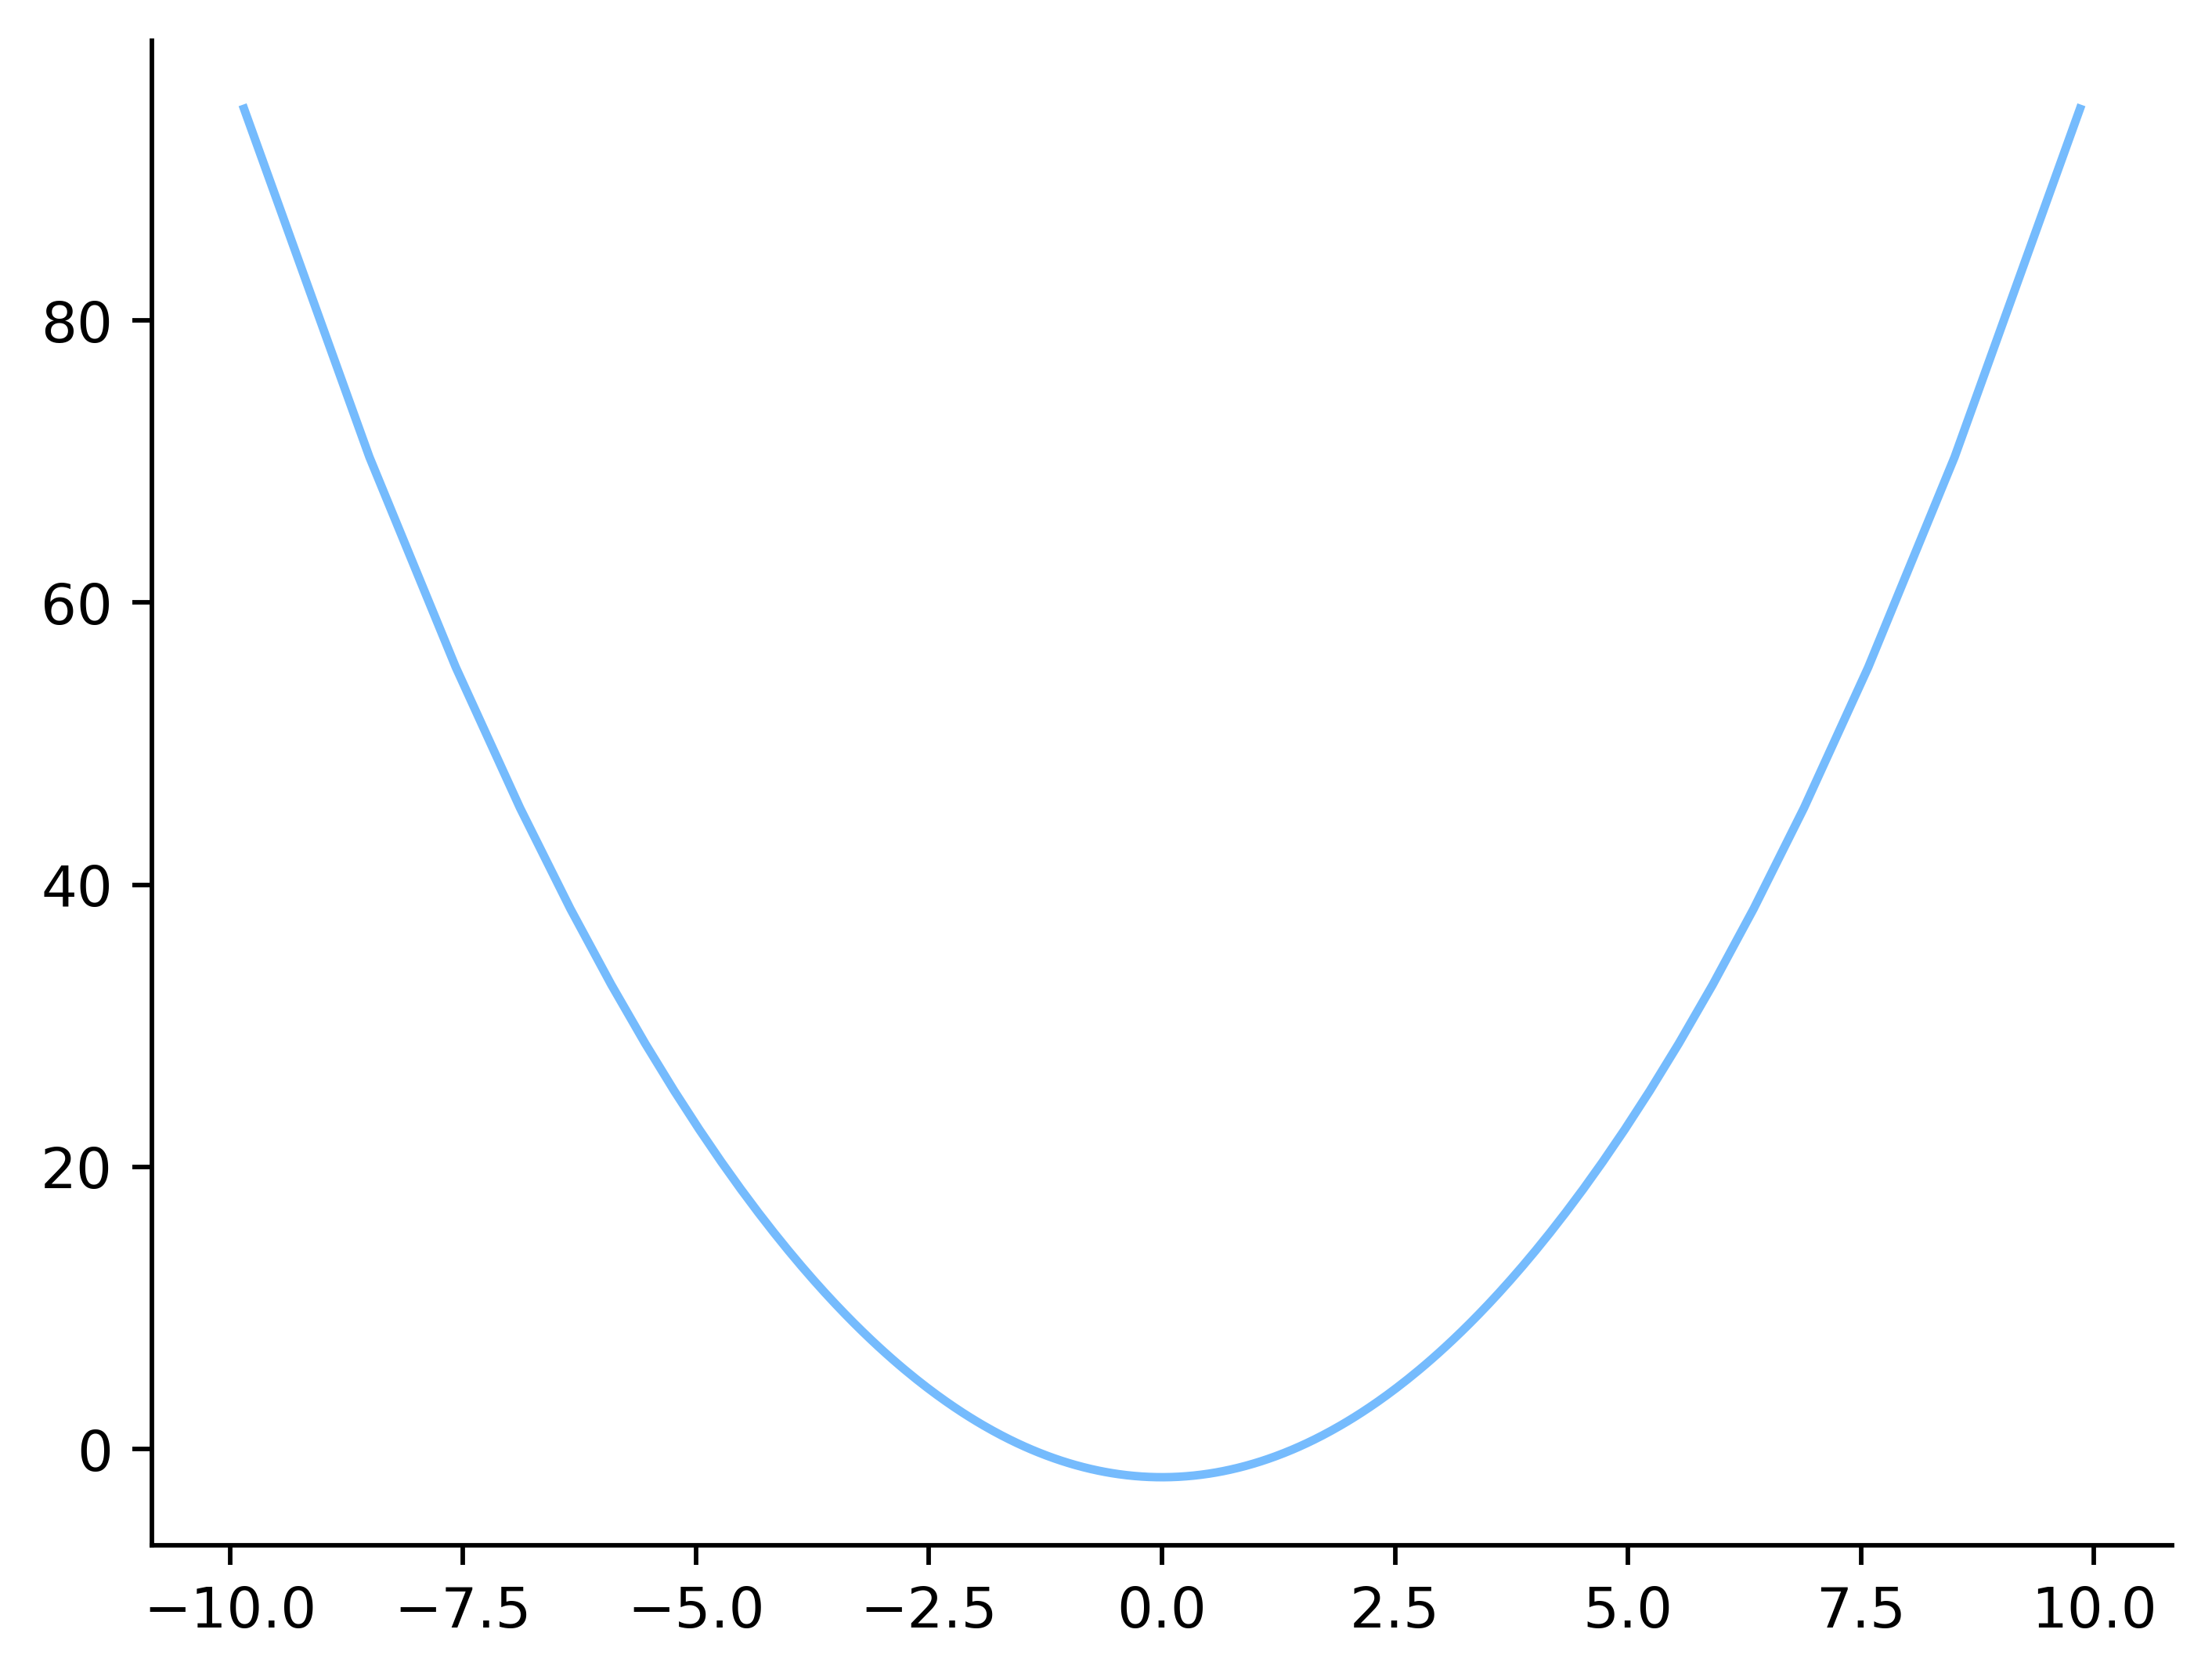

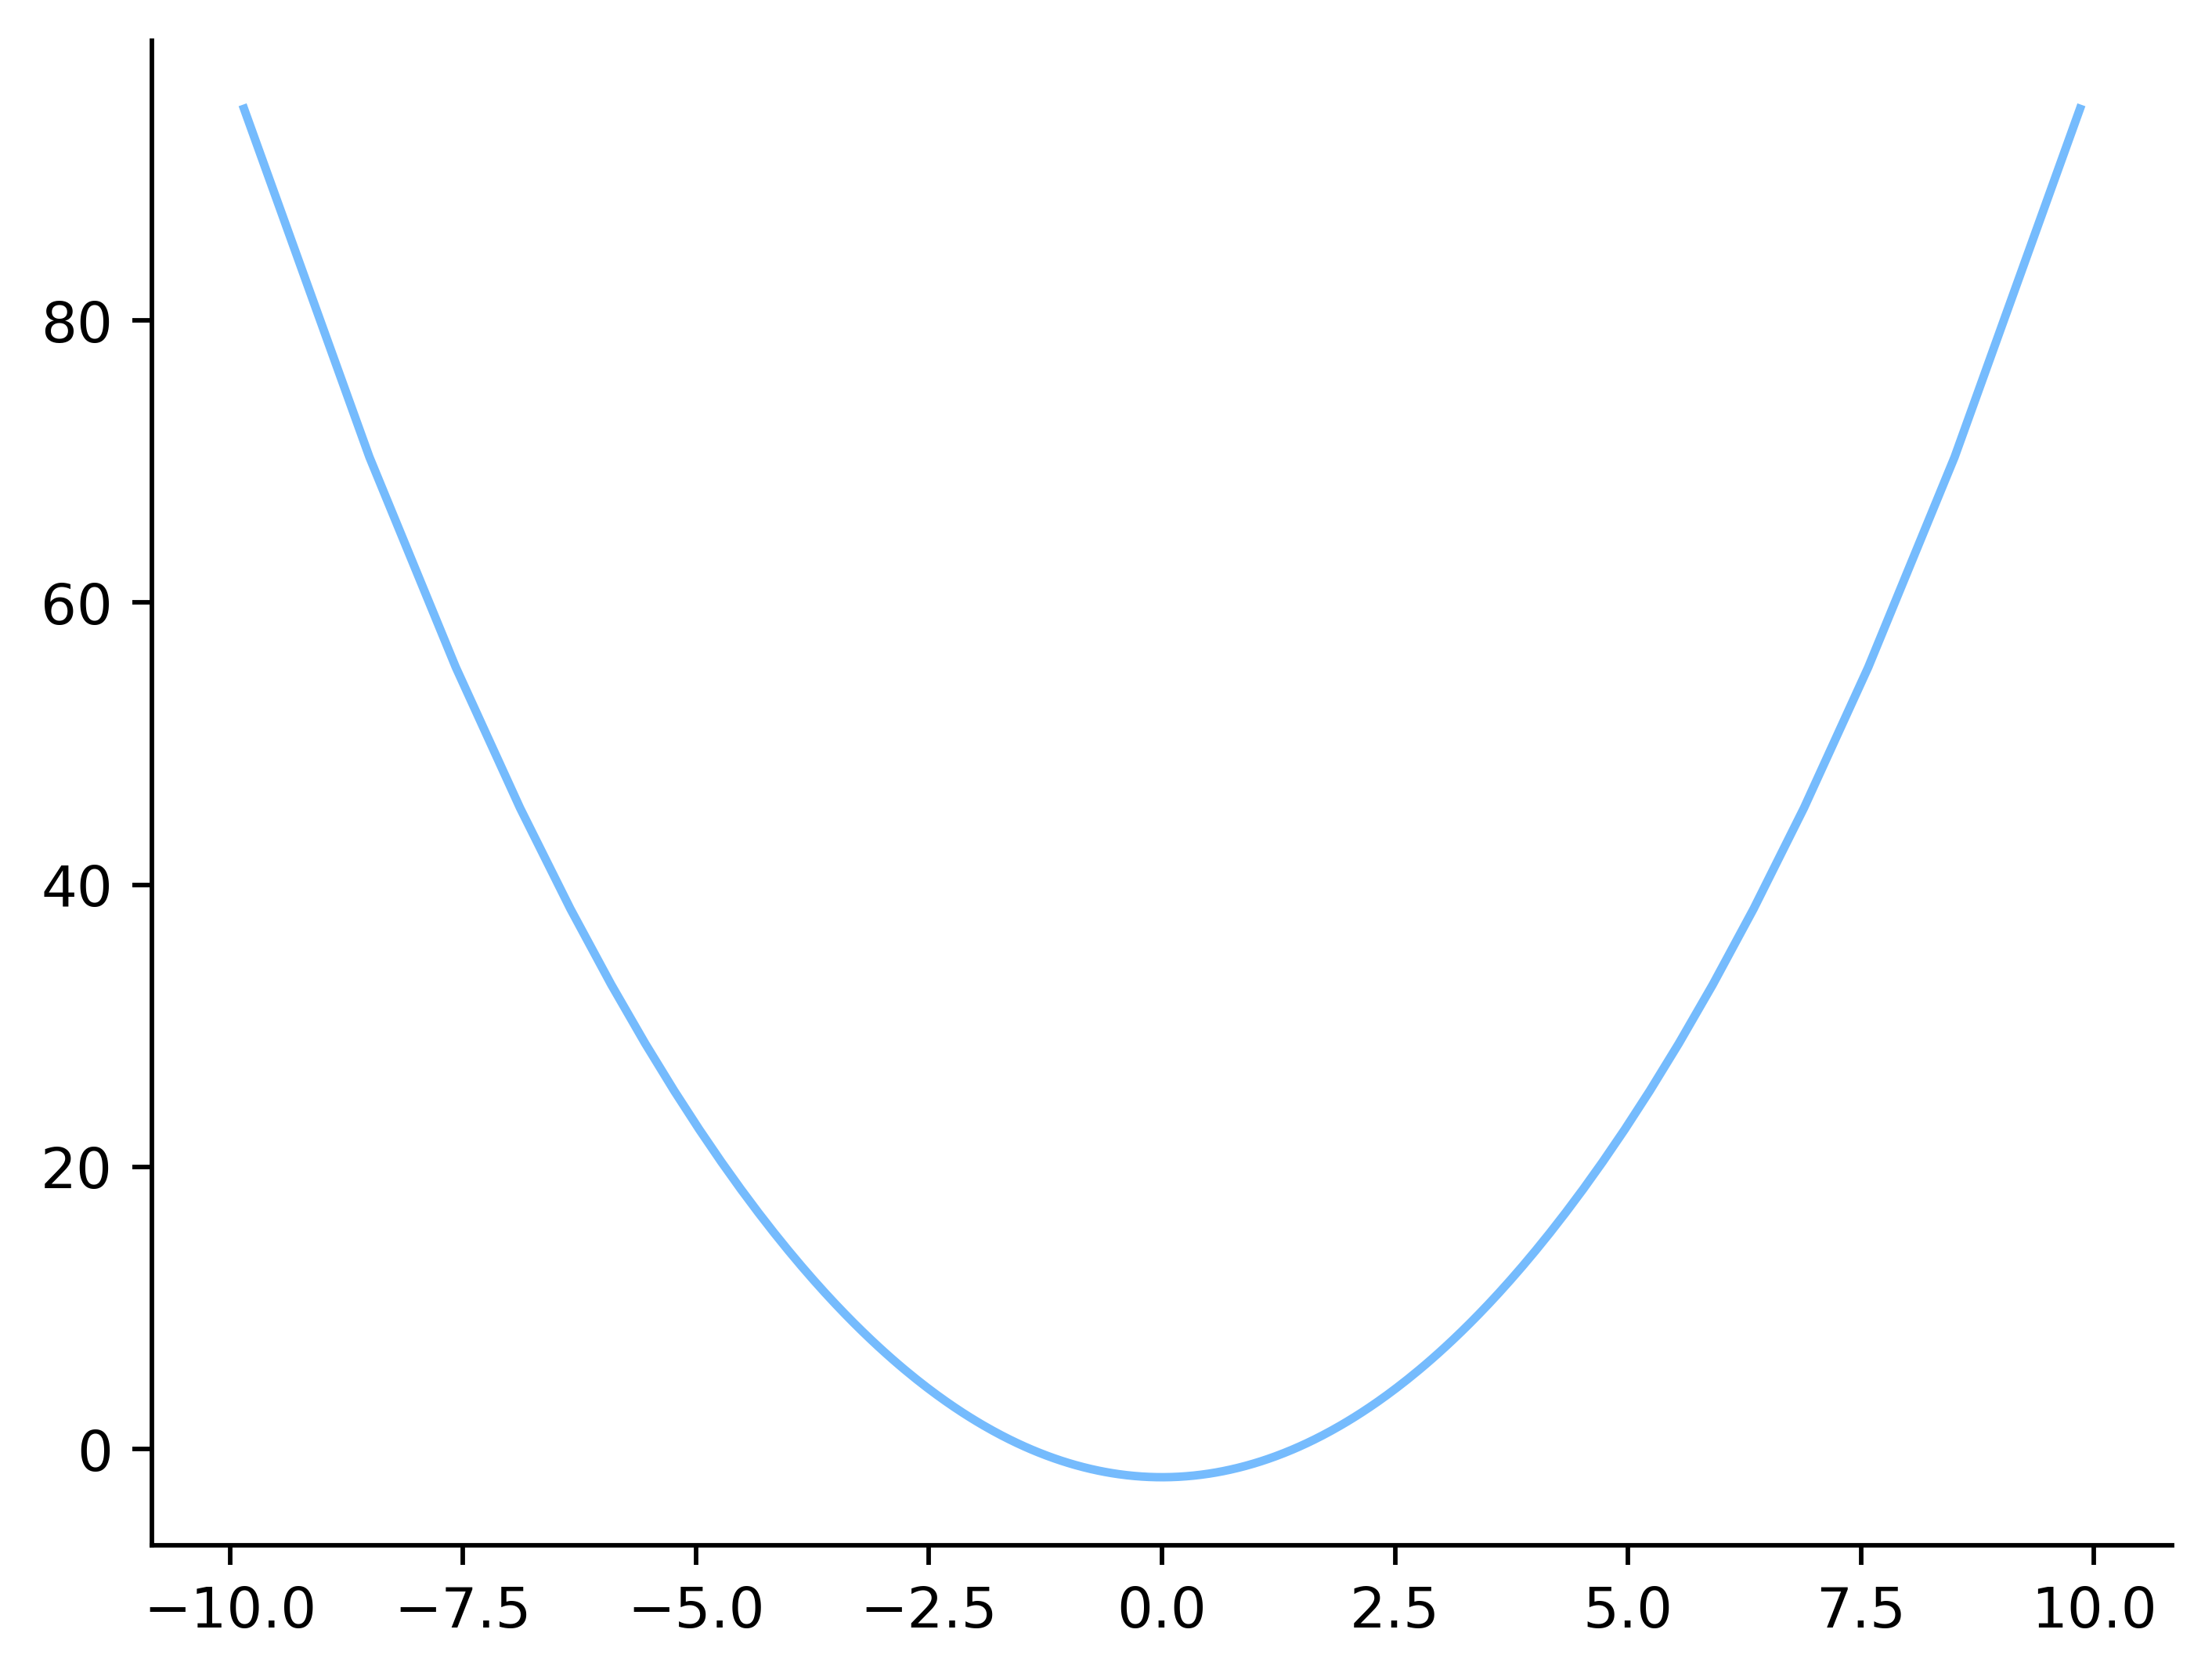

In [2]:
from myst_nb import glue

fig, ax = plt.subplots()

p = np.linspace(0.01, 0.99, 300)
skewness = (1 - 2*p) / (p * (1 - p))**0.5
kurtosis = 1 / (p * (1 - p)) - 6

plt.plot(skewness, kurtosis)
plt.show()

glue("bernoulli-sk-plot", fig, display=True)

```{glue:figure} bernoulli-sk-plot
:figwidth: 400pt
:name: "fig:bernoulli-sk-plot"

Il grafico skewness-curtosi per la famiglia delle distribuzioni di
Bernoulli.
```

(sec:bernoulli_quantiles)=
## Quantili della distribuzione di Bernoulli (*)

La distribuzione di Bernoulli ha solo due specificazioni, e di conseguenza
la sua funzione di ripartizione assume al massimo tre valori distinti, e ciò
ha un notevole impatto sui quantili della distribuzione stessa. Consideriamo
pertanto una variabile aleatoria $X \sim \mathrm B(p)$ e analizziamo
innanzitutto il caso $p \in (0, 1)$, per il quale si ha

\begin{equation*}
F_X(x) = \begin{cases}
    0     & \text{per $x < 0$} \enspace, \\
    1 - p & \text{per $0 \leq x < 1$} \enspace,  \\
    1     & \text{per $x \geq 1$} \enspace.
\end{cases}
\end{equation*}

Dato un generico livello $q \in (1-p, 1]$ si avrà

\begin{equation*}
x_q = \arg\min_x \{ F_X(x) \geq q \} = \arg\min_x \{ F_X(x) = 1 \}
    = \arg\min_x \{ x \geq 1 \} = 1 \enspace.
\end{equation*}

Analogamente, per ogni livello $q \in (0, 1-p]$

\begin{equation*}
x_q = \arg\min_x \{ F_X(x) \geq q \} = \arg\min_x \{ F_X(x) = 1-p \}
    = \arg\min_x \{ x \geq 0 \} = 0 \enspace.
\end{equation*}

Riassumendo, $0$ è il quantile per tutti i livelli $q \in (0, 1-p]$ e $1$
è il quantile per tutti i livelli successivi.

Rimangono da analizzare i casi $p = 0$ e $p = 1$. Consideriamo il secondo, nel
quale la variabile aleatoria degenera nella costante $1$, così che la sua
funzione di ripartizione diventa

\begin{equation*}
F_X(x) = \begin{cases}
    0     & \text{per $x < 1$} \enspace, \\
    1     & \text{per $x \geq 1$} \enspace,
\end{cases}
\end{equation*}

e quindi per ogni $q > 0$ si ha $x_q = \arg\min_x \{ F_X(x) \geq q \}
= \arg\min_x \{ F_X(x) = 1 \} = \arg\min_x \{ x \geq 1 \} = 1$. Dunque
il quantile di qualsiasi livello non nullo è uguale a $1$. Si verifica
facilmente che si ottiene un risultato analogo quando $p = 0$, con l'unica
differenza che ora, sempre indipendentemente dal livello $q > 0$, il quantile
è uguale a $0$.

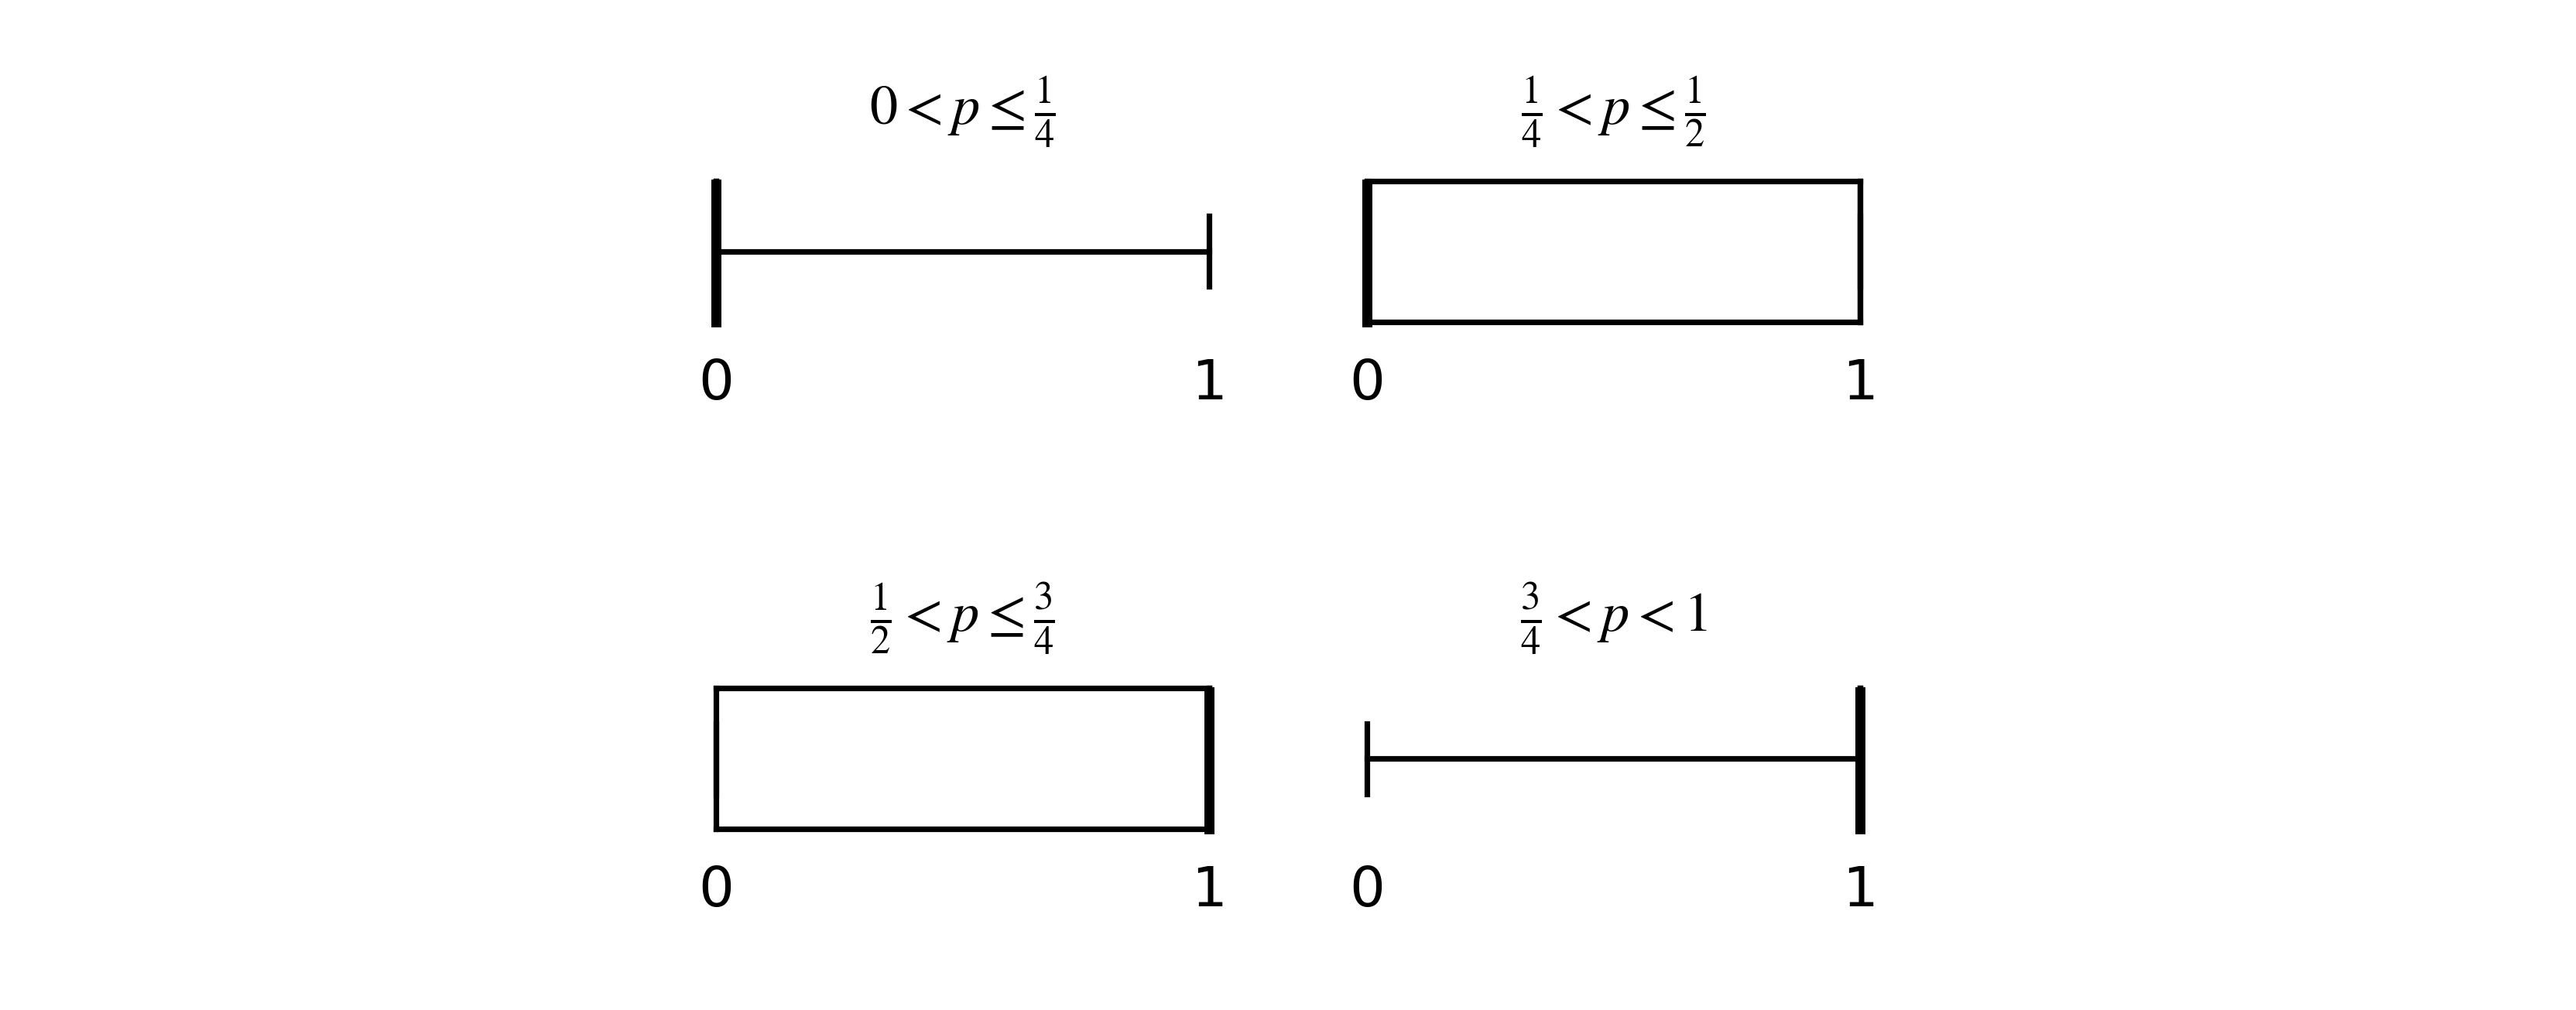

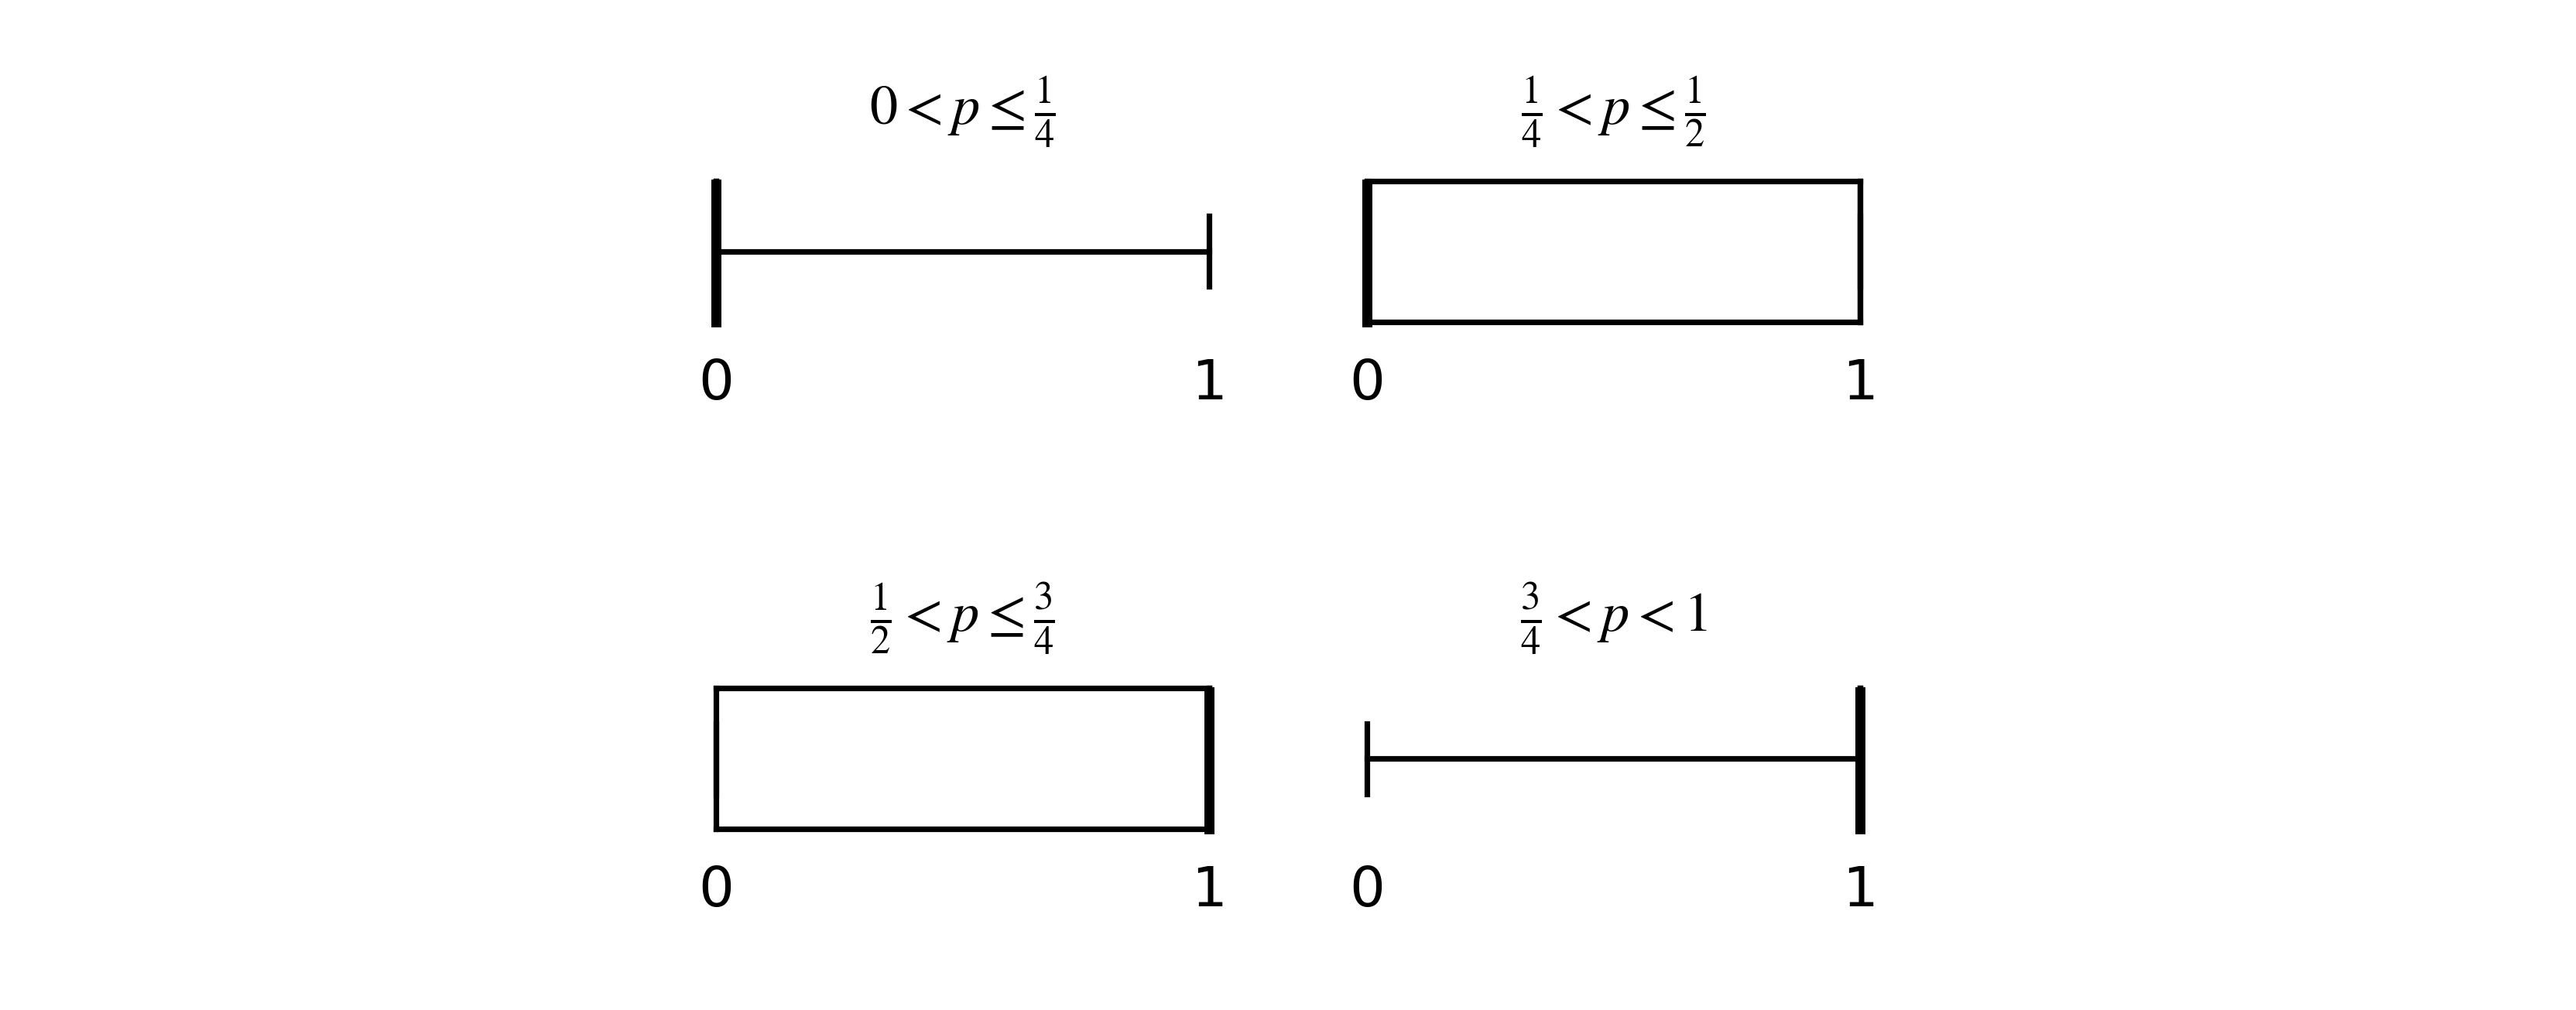

In [3]:
plt.style.use('matplotlibrc')

lw = 1
height = 0.1

def bernoulli_bp(q1, m, q3, ax, label):

    ax.plot([m, m], [-height, height*0.95], c='k', linewidth=1.8)

    ax.plot([0, 0], [-.05, .05], c='k', linewidth=lw)
    ax.plot([0, q1], [0, 0], c='k', linewidth=lw)

    ax.plot([q1, q1], [-height, height],
            c='k', linewidth=lw)

    ax.plot([q3, q3], [-height, height],
            c='k', linewidth=lw)

    ax.plot([q1, q3], [height, height],
            c='k', linewidth=lw)
    ax.plot([q1, q3], [-height, -height],
            c='k', linewidth=lw)

    ax.plot([q3, q3], [-height, height],
            c='k', linewidth=lw)
    ax.plot([q3, 1], [0, 0], 'k', linewidth=lw)
    ax.plot([1, 1], [-0.05, 0.05], 'k', linewidth=lw)

    ax.text(0, -.21, '0', ha='center')
    ax.text(1, -.21, '1', ha='center')
    ax.text(0.5, .18, label, ha='center')

    ax.set_ylim(-.3, .3)

fig, axes = plt.subplots(2, 4,figsize=(8, 3))
bernoulli_bp(0, 0, 0, axes[0, 1], r'$0 < p \leq \frac{1}{4}$')
bernoulli_bp(0, 0, 1, axes[0, 2], r'$\frac{1}{4} < p \leq \frac{1}{2}$')
bernoulli_bp(0, 1, 1, axes[1, 1], r'$\frac{1}{2} < p \leq \frac{3}{4}$')
bernoulli_bp(1, 1, 1, axes[1, 2], r'$\frac{3}{4} < p < 1$')

for a in axes.flatten():
    a.axis('off')

plt.show()


glue("bernoulli-bp", fig)

```{glue:figure} bernoulli-bp
:name: fig:bernoulli-bp
:figwidth: 100%

I possibili diagrammi a scatola per una distribuzione di Bernoulli, in
funzione del valore assunto dal relativo parametro $p$. I casi $p = 0$ e
$p = 1$ sono esclusi.

```

Essendo i quantili per la distribuzione di Bernoulli sempre uguali a $0$ o a
$1$, non risulta affatto utile disegnare il suo diagramma a scatola, perché
si otterrebbe sempre un grafico senza scatola o senza baffi. Più precisamente,
come evidenziato dalla {numref}`Figura %s<fig:bernoulli-bp>`:

- quando $0 < p \leq \frac{1}{4}$ il primo e il terzo quartile, e quindi anche
  la mediana, sono uguali a $0$, dunque la scatola del diagramma collassa in
  un segmento verticale sovrapposto all'estremo del baffo sinistro;
- quando $\frac{1}{4} < p \leq \frac{1}{2}$ il primo quartile e la mediana
  si annullano mentre il terzo quartile è uguale a $1$, quindi la scatola
  occupa tutto l'intervallo $[0, 1]$ e i baffi scompaiono, e il segmento che
  evidenzia la mediana coincide con l'estremo sinistro della scatola;
- quando $\frac{1}{2} < p \leq \frac{3}{4}$ il primo quartile è nullo mentre
  la mediana e il terzo quartile sono uguali a $1$, pertanto il grafico è
  analogo a quello descritto nel punto precedente, con l'unica differenza che
  la mediana è evidenziata sovrapponendola all'estremo destro della scatola;
- quando $\frac{3}{4} < p \leq 1$ i primi tre quartili sono tutti uguali a
  $1$, quindi la scatola collassa in un segmento verticale sovrapposto
  all'estremo del baffo destro. 

Nella figura non sono contemplati i casi $p = 0$ e $p = 1$, per i quali la
distribuzione è degenere e le variabili aleatorie corrispondenti vanno
rispettivamente a coincidere con le costanti $0$ e $1$, e dunque i primi tre
quartili, così come il minimo e il massimo delle specificazioni, coincidono
queste costanti. Pertanto, l'intero diagramma collassa in un segmento
verticale posizionato nel primo caso nell'ascissa nulla e nel secondo in
quella unitaria.



## Implementazione della distribuzione di Bernoulli (*)

Il modulo `scipy.stats` contiene una serie di classi che implementano le
famiglie di distribuzioni comunemente utilizzate, e in particolare quasi tutte
quelle che ho descritto in questo libro. Più precisamente, sulle istanze di
queste classi è possibile invocare metodi che permettono di calcolare
automaticamente gli indici e le funzioni che abbiamo studiato. Il punto di partenza per
ottenere tali istanze consiste nell'invocare una funzione specifica per ogni
famiglia di distribuzioni, che si occupa di creare le istanze e di
restituirle. Questa funzione ha un nome che ricorda quello della famiglia a
cui essa fa riferimento, e per quanto riguarda le distribuzioni discrete
essa accetta un argomento per ogni valore dei parametri coinvolti.

Per quanto riguarda le distribuzioni di Bernoulli, questa funzione si chiama
(banalmente) `bernoulli`, e la cella che segue mostra come ottenere le
corrispondenti istanze.

```{margin}
Va notato che in questa cella ho violato la convenzione che richiede di non
iniziare il nome di una variabile con una lettera maiuscola. D'altronde,
questa variabile `X` (nel contesto della programmazione) è la naturale
controparte di una variabile aleatoria $X$ (nel contesto del calcolo delle
probabilità). Per essere coerente con la notazione matematica che ho
utilizzato nel resto del libro ho scelto, in casi come questo, di utilizzare
come nome delle variabili coinvolte delle lettere maiuscole.
```

In [4]:
import scipy.stats as st

X = st.bernoulli(0.7)

Una volta istanziata una distribuzione discreta, i metodi `pmf` e `cdf`
permettono di calcolarne le funzioni di massa di probabilità e di
ripartizione.

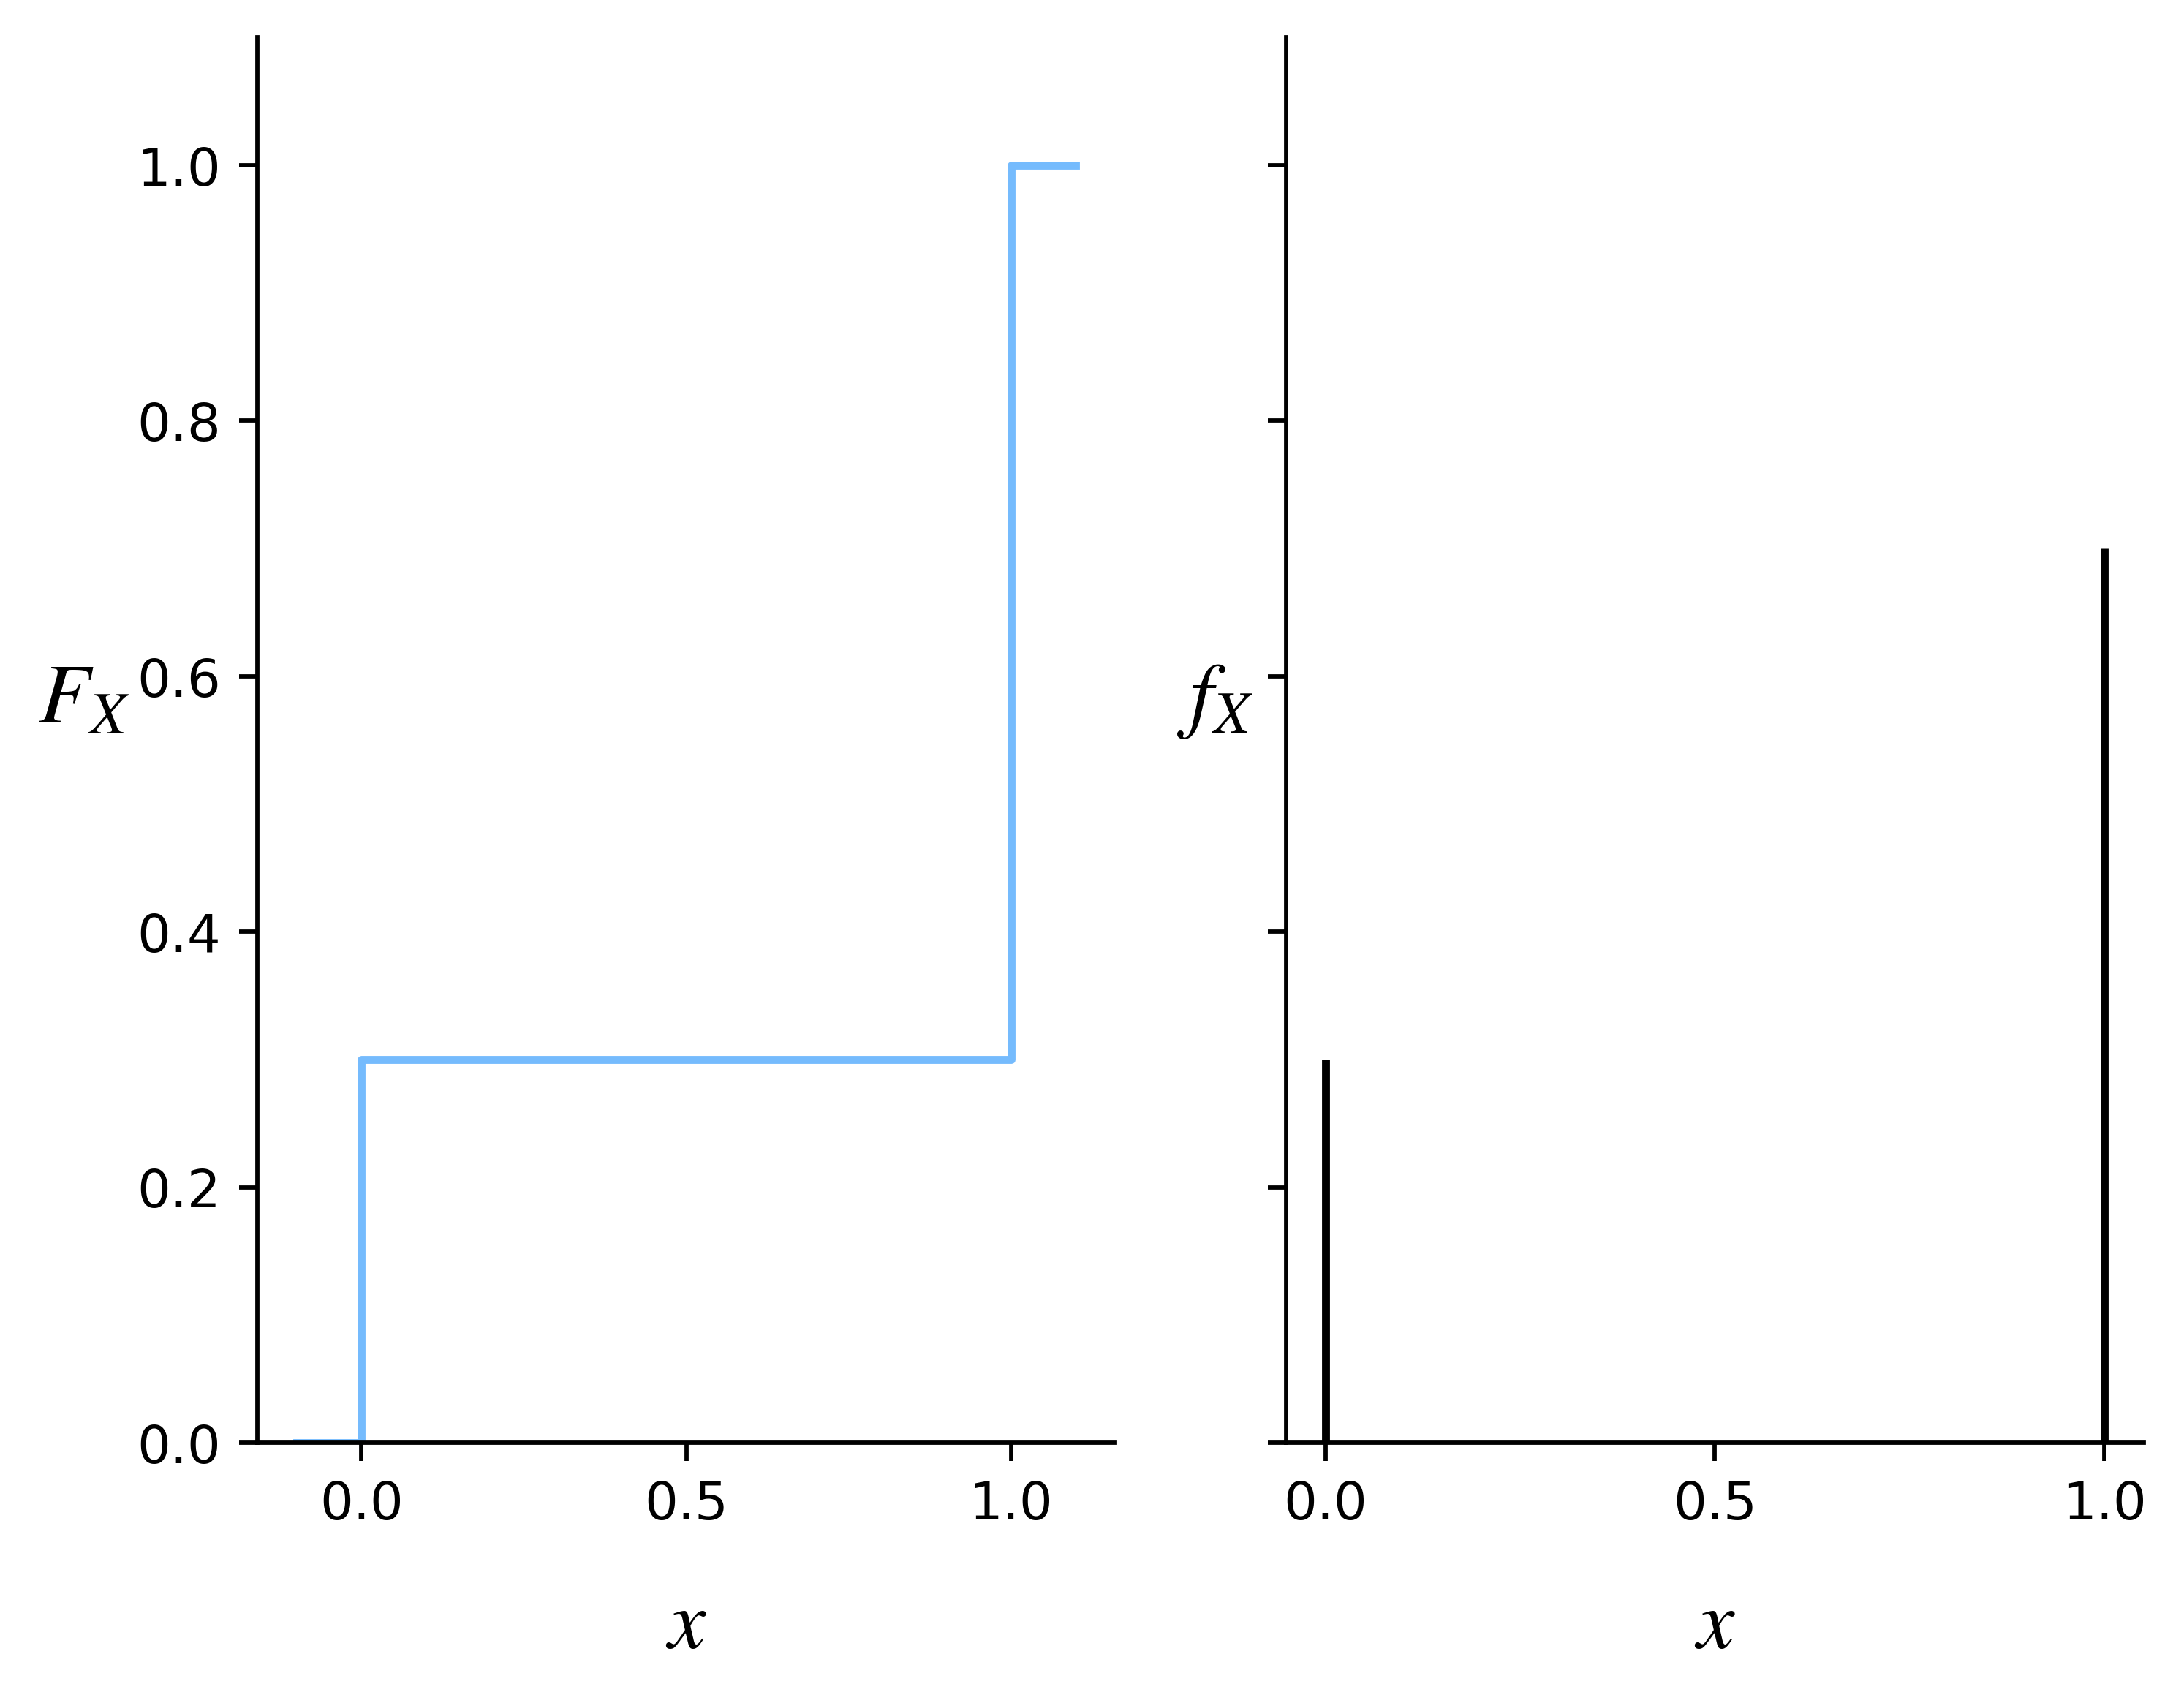

In [5]:
p=0.7
fig, axes = plt.subplots(1, 2, sharey=True)

B = st.bernoulli(p)
x = np.arange(-0.1, 1.1, 0.01)

axes[0].step(x, B.cdf(x))
axes[1].vlines(B.support(), 0, B.pmf(B.support()), color='k')

for ax in axes:
    ax.set_ylim(0, 1.1)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xlabel(r'$x$')

axes[0].set_ylabel(r'$F_X$', rotation='horizontal')
axes[1].set_ylabel(r'$f_X$', rotation='horizontal')
plt.show()

Analogamente, i metodi `mean`, `median`, `var` e `std` permettono di calcolare
valore atteso, mediana, varianza e deviazione standard della distribuzione.

In [6]:
print(f'Per la distribuzione di Bernoulli di parametro {p} si ha')
print(f'valore atteso {B.mean():.2f}')
print(f'mediana {B.median():.2f}')
print(f'varianza {B.var():.2f}')
print(f'deviazione standard {B.std():.2f}')

Per la distribuzione di Bernoulli di parametro 0.7 si ha
valore atteso 0.70
mediana 1.00
varianza 0.21
deviazione standard 0.46


Inoltre, il metodo `ppf` calcola un generico quantile della distribuzione,
specificando come argomento il livello corrispondente. Per esempio, nella
cella seguente viene calcolato il range interquartile di una distribuzione di
Bernoulli di parametro $p = 0.7$ che, come abbiamo visto al termine del
{numref}`Paragrafo %s <sec:bernoulli_quantiles>`, vale $1$.

In [7]:
B.ppf(0.75) - B.ppf(0.25)

1.0

```{margin}
In questo caso la funzione di massa di probabilità è mostrata utilizzando
un diagramma a barre e non uno a bastoncini, altrimenti sarebbe stato
difficile distinguere le frequenze relative del campione con le probabilità
teoriche.
```
Infine, il metodo `rvs` permette di simulare l'estrazione di specificazioni
dalla distribuzione: nella cella seguente, vengono simulate $5000$
osservazioni di una variabile aleatoria di Bernoulli di parametro
$\frac{1}{2}$, e il diagramma a barre delle frequenze relative del campione
ottenuto viene confrontato con il grafico a bastoncini della funzione di massa
di probabilità. Anche in questo caso, nella versione interattiva del libro
è possibile modificare il valore del parametro della distribuzione di
Bernoulli e vedere come viene modificato il grafico.

In [8]:
import pandas as pd

plt.style.use('../../sds.mplstyle')

param_slider = widgets.FloatSlider(value=0.5,
                                        min=0,
                                        max=1,
                                        step=0.01,
                                        description='p',
                                        continuous_update=True,
                                        readout=False,
                                        orientation='horizontal')

def bernoulli_simulation(p):
    B = st.bernoulli(p)

    m = 5000
    x = B.rvs(m)
    freq = pd.Series(x).value_counts(normalize=True)
    freq = freq.reindex([0, 1], fill_value=0).values
    plt.bar([0, 1], freq, facecolor='lightgray', edgecolor='gray', width=.1)

    plt.vlines([0, 1], 0, [B.pmf(0), B.pmf(1)])
    plt.plot([0, 1], [B.pmf(0), B.pmf(1)], 'o')


    plt.ylim(0, 1.1)
    plt.show()

widgets.interactive(bernoulli_simulation, p = param_slider)

interactive(children=(FloatSlider(value=0.5, description='p', max=1.0, readout=False, step=0.01), Output()), _…